# Card Fraud Project

This is just to get started, I'm mainly focusing on data exploration and adding more features to the dataset

In [ ]:
#pip install pandas
#pip install scipy
#pip install seaborn
#pip install jupyter
#pip install build
#pip install setuptools
#pip install wheel

In [3]:
import pandas as pd
import scipy as sp
import seaborn as sns



In [4]:
pip install git+https://github.com/jeffallen13/cardsim.git

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/jeffallen13/cardsim.git to c:\users\kdeb2\appdata\local\temp\pip-req-build-6jzw3a9o
  Resolved https://github.com/jeffallen13/cardsim.git to commit eb8b73cf78a6f3267c219417a79b9d1e4d8c9c5e
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for cardsim: filename=cardsim-1.0.0-py3-none-any.whl size=5144006 sha256=e72590f65ccd7cf4dc3d87585da54932bbebf2fa890dcd212092716dab0eb71f
  Stored in directory: C:\Users\kdeb2\AppData\Local\Temp\pip-ephem-wheel-cache-f1dgg_ss\wheels\a5\61\26\c6584e346da2d602dc1ca9714fbabd9207711008bd3f07f4aa
Successfully built cardsim
Note: you may need to restart the kern

  Running command git clone --filter=blob:none --quiet https://github.com/jeffallen13/cardsim.git 'C:\Users\kdeb2\AppData\Local\Temp\pip-req-build-6jzw3a9o'

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\kdeb2\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
#The following code is from vignette.py from the cardsim github
from importlib import resources
from cardsim import Cardsim

dcpc_path = resources.files("cardsim.dcpc")

simulator = Cardsim(seed=212, dcpc_folder=dcpc_path)
#Simulate has three hidden variables, n_payers (number of payers, default is 10000), n_days, number of days the simulator should run, default is 365) and start date, which the default for is '2023-01-01'

df = simulator.simulate()

simulator.export_transaction_data(df, folder='data')

params = simulator.export_run_parameters(
    df, folder='data', file_name='cardsim_runs'
)

Sourcing DCPC data
Sourcing successful; formatting data
DCPC data sourcing and formatting complete
Starting phase one: generating simulator world


Generated payment distributions

Generating payer profiles for 10000 payers
Generated payer profiles

Generating payee profiles for 1000 payees
Generated payee profiles

Calculated distance matrix

Generated world in 2 seconds

Starting phase two: generating transactions within world

Generated baseline transactions

Generated card type attribute

Generated location type attribute

Generated transaction amount

Generated and added payee distance
Generated transaction time

Generated fraud flag

Generated transactions in 6 seconds

Simulator completed in 9 seconds

Saving data to data/transaction-data-S212P10000D365


In [7]:
display(df)

,run_id,day_index,date,time_seconds,hour,date_time,payer_id,payee_id,credit_card,remote,distance,amount,fraud
0,S212P10000D365,0,2023-01-01,43856,12,2023-01-01 12:10:56,0,389,1,0,179.627396,16.255980,0
1,S212P10000D365,0,2023-01-01,17537,4,2023-01-01 04:52:17,0,563,0,1,149.093933,20.286731,0
2,S212P10000D365,0,2023-01-01,75047,20,2023-01-01 20:50:47,1,718,1,1,99.080772,7.750864,0
3,S212P10000D365,0,2023-01-01,58973,16,2023-01-01 16:22:53,2,540,0,1,145.361618,16.549327,0
4,S212P10000D365,0,2023-01-01,41136,11,2023-01-01 11:25:36,2,309,0,0,63.324562,15.847432,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3601052,S212P10000D365,364,2023-12-31,72192,20,2023-12-31 20:03:12,9997,520,0,0,97.862144,16.258811,0
3601053,S212P10000D365,364,2023-12-31,57763,16,2023-12-31 16:02:43,9997,929,0,1,151.792618,29.980362,0
3601054,S212P10000D365,364,2023-12-31,29981,8,2023-12-31 08:19:41,9999,377,0,0,134.014923,46.485286,0
3601055,S212P10000D365,364,2023-12-31,42857,11,2023-12-31 11:54:17,9999,115,0,1,58.309521,16.746186,0


In [8]:
print("Data points for the dataset:")
print(len(df))

Data points for the dataset:
3601057


In [9]:
print(df.isna().sum())

run_id          0
day_index       0
date            0
time_seconds    0
hour            0
date_time       0
payer_id        0
payee_id        0
credit_card     0
remote          0
distance        0
amount          0
fraud           0
dtype: int64


In [19]:
print(df['payer_id'].nunique())

10000


In [20]:
print(df['payee_id'].nunique())

1000


In [26]:
print(df['distance'].nunique())

12194


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3601057 entries, 0 to 3601056
Data columns (total 13 columns):
 #   Column        Dtype         
---  ------        -----         
 0   run_id        object        
 1   day_index     int64         
 2   date          datetime64[ns]
 3   time_seconds  int64         
 4   hour          int32         
 5   date_time     datetime64[ns]
 6   payer_id      int64         
 7   payee_id      int64         
 8   credit_card   int64         
 9   remote        int64         
 10  distance      float32       
 11  amount        float64       
 12  fraud         int64         
dtypes: datetime64[ns](2), float32(1), float64(1), int32(1), int64(7), object(1)
memory usage: 329.7+ MB


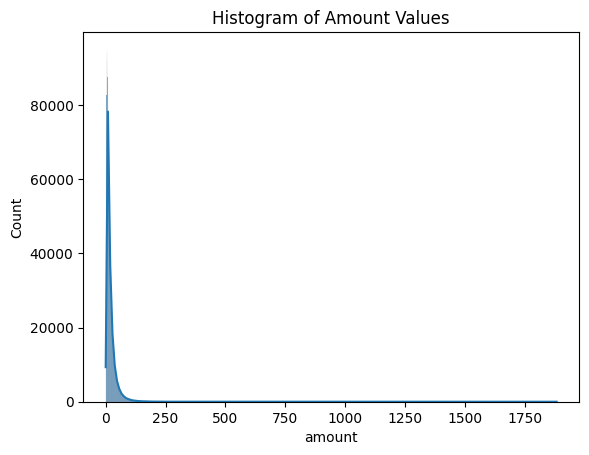

In [27]:
amount_values = df['amount']
#We plot amount so we can see what the distribution looks like
import matplotlib.pyplot as plt
sns.histplot(amount_values, kde=True)
plt.title("Histogram of Amount Values")
plt.show()

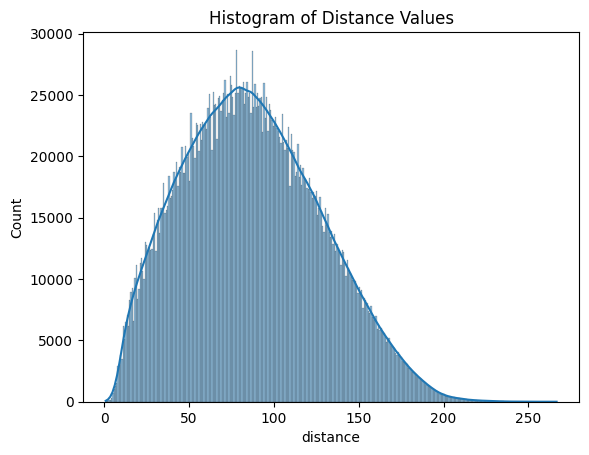

In [40]:
distance_values = df['distance']
#We plot distance so we can see what the distribution looks like
import matplotlib.pyplot as plt
sns.histplot(distance_values, kde=True)
plt.title("Histogram of Distance Values")
plt.show()

<Axes: xlabel='fraud'>

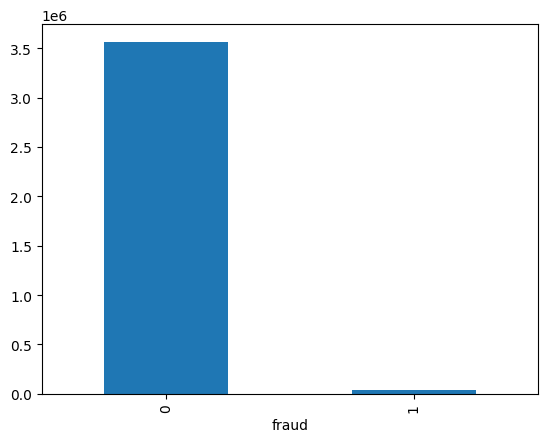

In [32]:
df['fraud'].value_counts().plot(kind='bar')

In [37]:
num_fraud_cases = df['fraud'].value_counts().get(1,0)
print(num_fraud_cases)
num_normal_cases = df['fraud'].value_counts().get(0,0)
print(num_normal_cases)

36015
3565042


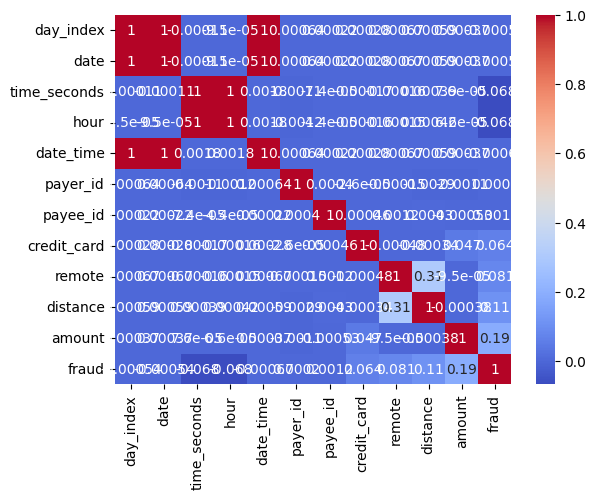

In [18]:
df_quanitative = df.drop('run_id', axis=1)
corr_df = df_quanitative.corr()
#Show heatmap of original features
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.show()